# Notebook 12 — LayoutLMv3 Fine-Tuning

Fine-tunes `microsoft/layoutlmv3-base` for token classification on the
FATURA invoice field extraction task prepared in Notebook 11.

**Model:** `microsoft/layoutlmv3-base`  
**Task:** Token classification (NER) — 13 BIO labels  
**Fields:** INVOICE_NUMBER, INVOICE_DATE, DUE_DATE, ISSUER_NAME, RECIPIENT_NAME, TOTAL_AMOUNT  
**Evaluation:** entity-level F1 via `seqeval`  
**Early stopping:** patience 3 on val entity F1  

> **No generative AI** — LayoutLMv3 is a discriminative encoder-only model.

## 0. Dependencies

In [1]:
import sys
print(sys.executable)
# Must show .venv311, NOT CommandLineTools

/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv311/bin/python


In [2]:
import IPython, traitlets, ipykernel
print(IPython.__version__, traitlets.__version__, ipykernel.__version__)


9.10.1 5.14.3 7.2.0


In [3]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg_name, import_name in [('datasets', 'datasets'), ('seqeval', 'seqeval')]:
    try:
        __import__(import_name)
        print(f'{pkg_name} already installed')
    except ImportError:
        print(f'Installing {pkg_name}…')
        pip_install(pkg_name)
        print(f'{pkg_name} installed')

/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets already installed
seqeval already installed


## 1. Imports & configuration

In [4]:
import os, time

# ── Environment variables must be set BEFORE the tokenizers/transformers
# ── Rust extension is loaded. Setting them here and importing in the
# ── same cell guarantees correct ordering after a clean kernel restart.
os.environ['TOKENIZERS_PARALLELISM'] = 'false'   # prevents Rust thread-pool deadlock in DataLoader workers
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['HF_HUB_OFFLINE'] = '1'               # no network calls after initial download
os.environ['TRANSFORMERS_OFFLINE'] = '1'

t0 = time.time()
# Import after env vars are set — this is the ONLY place these are imported.
# Do NOT import transformers or tokenizers in any earlier cell.
from transformers import LayoutLMv3ForTokenClassification, LayoutLMv3Processor
print('import_ok_sec:', round(time.time() - t0, 2))


import_ok_sec: 3.58


In [5]:
import json
import random
from pathlib import Path

import numpy as np
import torch
from PIL import Image
print(f'PIL version: {Image.__version__}')
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
# LayoutLMv3ForTokenClassification and LayoutLMv3Processor already imported in Cell 5
from datasets import load_from_disk
from seqeval.metrics import classification_report as seq_report, f1_score as seq_f1
print(f'PyTorch version    : {torch.__version__}')

import transformers
print(f'Transformers version: {transformers.__version__}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path('..').resolve()
DATASET_DIR   = PROJECT_ROOT / 'data' / 'processed' / 'layoutlmv3_dataset'
MODEL_OUT_DIR = PROJECT_ROOT / 'models' / 'experimental' / 'layoutlmv3_fatura'
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
BASE_MODEL   = 'microsoft/layoutlmv3-base'
EPOCHS       = 10
LR           = 1e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE   = 2    # LayoutLMv3 is memory-heavy; keep batch small
PATIENCE     = 3    # early-stopping patience (val entity F1)
MAX_LENGTH   = 512

DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Dataset dir: {DATASET_DIR}')
print(f'Model output: {MODEL_OUT_DIR}')


PIL version: 12.2.0
PyTorch version    : 2.11.0
Transformers version: 5.5.4
Device: mps
Dataset dir: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/processed/layoutlmv3_dataset
Model output: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/layoutlmv3_fatura


## 2. Load label schema & dataset

In [6]:
with open(DATASET_DIR / 'label2id.json') as f:
    label2id = json.load(f)
with open(DATASET_DIR / 'id2label.json') as f:
    id2label = {int(k): v for k, v in json.load(f).items()}

NUM_LABELS = len(label2id)
BIO_LABELS = [id2label[i] for i in range(NUM_LABELS)]

print(f'Labels ({NUM_LABELS}):', BIO_LABELS)

raw_dataset = load_from_disk(str(DATASET_DIR))
print('\nDataset loaded:')
print(raw_dataset)

Labels (13): ['O', 'B-INVOICE_NUMBER', 'I-INVOICE_NUMBER', 'B-INVOICE_DATE', 'I-INVOICE_DATE', 'B-DUE_DATE', 'I-DUE_DATE', 'B-ISSUER_NAME', 'I-ISSUER_NAME', 'B-RECIPIENT_NAME', 'I-RECIPIENT_NAME', 'B-TOTAL_AMOUNT', 'I-TOTAL_AMOUNT']

Dataset loaded:
DatasetDict({
    train: Dataset({
        features: ['image_path', 'words', 'bboxes', 'ner_tags'],
        num_rows: 1734
    })
    val: Dataset({
        features: ['image_path', 'words', 'bboxes', 'ner_tags'],
        num_rows: 371
    })
    test: Dataset({
        features: ['image_path', 'words', 'bboxes', 'ner_tags'],
        num_rows: 372
    })
})


## 3. Processor & tokenisation

In [7]:
from pathlib import Path
from huggingface_hub import snapshot_download

HF_CACHE = Path('/tmp/hf_cache_layoutlmv3')
HF_CACHE.mkdir(parents=True, exist_ok=True)

# Check if snapshot already exists locally before attempting any download.
# snapshot_download with local_dir_use_symlinks=False writes files flat.
# We detect the snapshot by looking for an existing config.json inside any snapshot dir.
existing_snapshots = sorted(
    (HF_CACHE / 'models--microsoft--layoutlmv3-base' / 'snapshots').glob('*/config.json')
) if (HF_CACHE / 'models--microsoft--layoutlmv3-base' / 'snapshots').exists() else []

if existing_snapshots:
    LOCAL_BASE_MODEL_DIR = str(existing_snapshots[-1].parent)
    print('Using existing local snapshot:', LOCAL_BASE_MODEL_DIR)
else:
    # Temporarily re-enable network for the one-time download
    import os as _os
    _os.environ['HF_HUB_OFFLINE'] = '0'
    _os.environ['TRANSFORMERS_OFFLINE'] = '0'
    print('No local snapshot found — downloading', BASE_MODEL, '...')
    allow_patterns = [
        'config.json', 'preprocessor_config.json',
        'tokenizer.json', 'tokenizer_config.json',
        'vocab.json', 'merges.txt',
        'special_tokens_map.json',
        'pytorch_model.bin', 'model.safetensors',
        'sentencepiece.bpe.model',
    ]
    LOCAL_BASE_MODEL_DIR = snapshot_download(
        repo_id=BASE_MODEL,
        cache_dir=str(HF_CACHE),
        resume_download=True,
        allow_patterns=allow_patterns,
    )
    # Re-enable offline mode now that we have the files
    _os.environ['HF_HUB_OFFLINE'] = '1'
    _os.environ['TRANSFORMERS_OFFLINE'] = '1'
    print('Download complete. Snapshot at:', LOCAL_BASE_MODEL_DIR)

print('LOCAL_BASE_MODEL_DIR:', LOCAL_BASE_MODEL_DIR)


No local snapshot found — downloading microsoft/layoutlmv3-base ...


/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv311/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 7 files: 100%|██████████| 7/7 [00:33<00:00,  4.84s/it]

Download complete. Snapshot at: /tmp/hf_cache_layoutlmv3/models--microsoft--layoutlmv3-base/snapshots/cfbbbff0762e6aab37086fdd4739ad14fe7d5db4
LOCAL_BASE_MODEL_DIR: /tmp/hf_cache_layoutlmv3/models--microsoft--layoutlmv3-base/snapshots/cfbbbff0762e6aab37086fdd4739ad14fe7d5db4


In [8]:
import torch, transformers, tokenizers, huggingface_hub
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("hf_hub:", huggingface_hub.__version__)
print("mps available:", torch.backends.mps.is_available())


torch: 2.11.0
transformers: 5.5.4
tokenizers: 0.22.2
hf_hub: 1.11.0
mps available: True


In [9]:
# Load processor from local snapshot.
#
# IMPORTANT — use_fast=True (NOT False):
#   use_fast=False forces the pure-Python sentencepiece tokenizer which
#   deadlocks on macOS Python 3.9 during initialization.
#   use_fast=True uses the Rust-backed fast tokenizer which is safe as long
#   as TOKENIZERS_PARALLELISM=false is set (done in Cell 5).
#
processor = LayoutLMv3Processor.from_pretrained(
    LOCAL_BASE_MODEL_DIR,
    apply_ocr=False,
    local_files_only=True,
    use_fast=True,          # ← fixes the macOS/Python3.9 deadlock
)
print('processor loaded OK')
print('  tokenizer type:', type(processor.tokenizer).__name__)


The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


processor loaded OK
  tokenizer type: LayoutLMv3Tokenizer


## 4. PyTorch Dataset & DataLoaders

In [10]:
# ── encode_example ────────────────────────────────────────────────────────────
# This function must be defined before FaturaTokenDataset because the Dataset
# __getitem__ calls it. It was missing from the original notebook.

def encode_example(example):
    """
    Encode a single HuggingFace dataset example into LayoutLMv3 model inputs.

    Expected example keys: 'words', 'bboxes', 'ner_tags', 'image_path'
    Returns a dict of tensors ready for the model.
    """
    image = Image.open(example['image_path']).convert('RGB')
    words  = example['words']
    boxes  = example['bboxes']
    labels = example['ner_tags']   # list of int label ids

    encoding = processor(
        image,
        words,
        boxes=boxes,
        word_labels=labels,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='pt',
    )
    # Squeeze batch dimension added by return_tensors='pt'
    return {k: v.squeeze(0) for k, v in encoding.items()}


# ── FaturaTokenDataset ────────────────────────────────────────────────────────
class FaturaTokenDataset(Dataset):
    """Wraps a HuggingFace Dataset split and applies LayoutLMv3 encoding on-the-fly."""

    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return encode_example(self.data[idx])


train_ds = FaturaTokenDataset(raw_dataset['train'])
val_ds   = FaturaTokenDataset(raw_dataset['val'])
test_ds  = FaturaTokenDataset(raw_dataset['test'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# num_workers=0 is required: non-zero workers re-import the tokenizers Rust
# extension in each worker process and cause a deadlock on macOS even with
# TOKENIZERS_PARALLELISM=false. Zero workers runs loading in the main process.

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')


Train batches: 867
Val batches  : 186
Test batches : 186


## 5. Model initialisation

In [11]:
# Load base model from local snapshot — no network call.
# The classification head is randomly initialised (ignore_mismatched_sizes=True)
# because the pre-trained head has a different number of labels.
model = LayoutLMv3ForTokenClassification.from_pretrained(
    LOCAL_BASE_MODEL_DIR,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
    local_files_only=True,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model loaded from : {LOCAL_BASE_MODEL_DIR}')
print(f'Total params      : {total_params:,}')
print(f'Trainable params  : {trainable:,}')


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 18956.09it/s]
LayoutLMv3ForTokenClassification LOAD REPORT from: /tmp/hf_cache_layoutlmv3/models--microsoft--layoutlmv3-base/snapshots/cfbbbff0762e6aab37086fdd4739ad14fe7d5db4
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.bias              | MISSING    | 
classifier.out_proj.weight         | MISSING    | 
classifier.dense.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded from : /tmp/hf_cache_layoutlmv3/models--microsoft--layoutlmv3-base/snapshots/cfbbbff0762e6aab37086fdd4739ad14fe7d5db4
Total params      : 125,927,565
Trainable params  : 125,927,565


In [12]:
# This cell previously contained a fallback model-loading block that tried
# BASE_MODEL (network) if LOCAL_BASE_MODEL_DIR failed. It was accidentally
# set to cell_type=markdown so it never executed.
#
# The fix in Cell 16 loads directly from LOCAL_BASE_MODEL_DIR with
# local_files_only=True, which is correct and sufficient.
# This cell is kept as a no-op placeholder to preserve cell numbering.
print('Cell 17: no-op placeholder (model already loaded in Cell 16)')


Cell 17: no-op placeholder (model already loaded in Cell 16)


In [13]:
def evaluate(model, loader):
    """
    Run inference over a DataLoader and compute seqeval entity-level F1.

    Returns (entity_f1: float, per_class_report: str).
    Tokens with label == -100 (padding / sub-token continuations) are ignored.
    """
    model.eval()
    all_preds, all_trues = [], []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            logits  = outputs.logits  # (B, seq_len, num_labels)
            preds   = logits.argmax(dim=-1)  # (B, seq_len)
            labels  = batch['labels']        # (B, seq_len)

            for pred_seq, true_seq in zip(preds, labels):
                pred_labels, true_labels = [], []
                for p, t in zip(pred_seq, true_seq):
                    if t.item() == -100:      # ignore padding / sub-tokens
                        continue
                    pred_labels.append(id2label[p.item()])
                    true_labels.append(id2label[t.item()])
                all_preds.append(pred_labels)
                all_trues.append(true_labels)

    entity_f1 = seq_f1(all_trues, all_preds)
    report    = seq_report(all_trues, all_preds, digits=4)
    return entity_f1, report

## 7. Training loop with early stopping

In [14]:
# Robust guard: rebuild dataloaders if kernel state lost.
if 'train_loader' not in globals() or 'val_loader' not in globals() or 'test_loader' not in globals():
    print('DataLoaders not found in memory. Rebuilding from raw_dataset ...')
    missing = [name for name in ['raw_dataset', 'encode_example', 'Dataset', 'DataLoader', 'BATCH_SIZE'] if name not in globals()]
    if missing:
        raise RuntimeError(
            'Cannot rebuild dataloaders because prerequisites are missing: ' + ', '.join(missing) +
            '. Re-run sections 1-4 first.'
        )

    class FaturaTokenDataset(Dataset):
        def __init__(self, hf_dataset):
            self.data = hf_dataset
        def __len__(self):
            return len(self.data)
        def __getitem__(self, idx):
            return encode_example(self.data[idx])

    train_ds = FaturaTokenDataset(raw_dataset['train'])
    val_ds   = FaturaTokenDataset(raw_dataset['val'])
    test_ds  = FaturaTokenDataset(raw_dataset['test'])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    print(f'Rebuilt loaders: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}')

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_f1   = -1.0
best_epoch    = -1
patience_left = PATIENCE
history       = []

CKPT_PATH = MODEL_OUT_DIR / 'best_checkpoint'

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(train_loader, 1):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        if step % 100 == 0 or step == len(train_loader):
            print(
                f'  Epoch {epoch}/{EPOCHS} | Step {step}/{len(train_loader)} | loss={loss.item():.4f}',
                end='\r'
            )

    avg_loss = total_loss / len(train_loader)

    val_f1, val_report = evaluate(model, val_loader)

    rec = {'epoch': epoch, 'train_loss': avg_loss, 'val_entity_f1': val_f1}
    history.append(rec)
    print(f'\nEpoch {epoch}/{EPOCHS} — train_loss={avg_loss:.4f}  val_entity_f1={val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1   = val_f1
        best_epoch    = epoch
        patience_left = PATIENCE
        model.save_pretrained(str(CKPT_PATH))
        processor.save_pretrained(str(CKPT_PATH))
        print(f'  New best val entity F1 = {best_val_f1:.4f} — checkpoint saved')
    else:
        patience_left -= 1
        print(f'  No improvement. Patience left: {patience_left}/{PATIENCE}')
        if patience_left == 0:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest val entity F1 = {best_val_f1:.4f} at epoch {best_epoch}')


  Epoch 1/10 | Step 867/867 | loss=0.0033
Epoch 1/10 — train_loss=0.1304  val_entity_f1=0.9994


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.81it/s]


  New best val entity F1 = 0.9994 — checkpoint saved
  Epoch 2/10 | Step 867/867 | loss=0.0009
Epoch 2/10 — train_loss=0.0066  val_entity_f1=1.0000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.40it/s]


  New best val entity F1 = 1.0000 — checkpoint saved
  Epoch 3/10 | Step 867/867 | loss=0.0005
Epoch 3/10 — train_loss=0.0067  val_entity_f1=1.0000
  No improvement. Patience left: 2/3
  Epoch 4/10 | Step 867/867 | loss=0.0003
Epoch 4/10 — train_loss=0.0011  val_entity_f1=1.0000
  No improvement. Patience left: 1/3
  Epoch 5/10 | Step 867/867 | loss=0.0002
Epoch 5/10 — train_loss=0.0035  val_entity_f1=1.0000
  No improvement. Patience left: 0/3
Early stopping at epoch 5

Best val entity F1 = 1.0000 at epoch 2


## 8. Test-set evaluation

In [15]:
# Load best checkpoint for test evaluation
best_model = LayoutLMv3ForTokenClassification.from_pretrained(
    str(CKPT_PATH),
    id2label=id2label,
    label2id=label2id,
)
best_model.to(DEVICE)

test_f1, test_report = evaluate(best_model, test_loader)
print(f'Test entity F1 (best checkpoint): {test_f1:.4f}')
print('\nPer-entity classification report:')
print(test_report)

Loading weights: 100%|██████████| 216/216 [00:00<00:00, 9479.05it/s]


Test entity F1 (best checkpoint): 1.0000

Per-entity classification report:
                precision    recall  f1-score   support

      DUE_DATE     1.0000    1.0000    1.0000       209
  INVOICE_DATE     1.0000    1.0000    1.0000       364
INVOICE_NUMBER     1.0000    1.0000    1.0000       328
   ISSUER_NAME     1.0000    1.0000    1.0000       241
RECIPIENT_NAME     1.0000    1.0000    1.0000       277
  TOTAL_AMOUNT     1.0000    1.0000    1.0000       298

     micro avg     1.0000    1.0000    1.0000      1717
     macro avg     1.0000    1.0000    1.0000      1717
  weighted avg     1.0000    1.0000    1.0000      1717



## 9. Training history plot

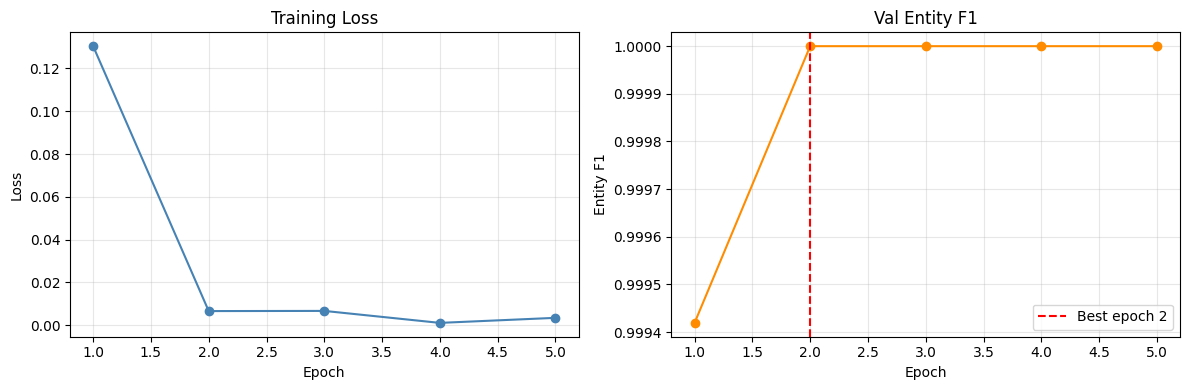

Plot saved to: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/layoutlmv3_fatura/training_history.png


In [16]:
import matplotlib.pyplot as plt

epochs_done = [r['epoch'] for r in history]
train_losses = [r['train_loss'] for r in history]
val_f1s      = [r['val_entity_f1'] for r in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_done, train_losses, marker='o', color='steelblue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_done, val_f1s, marker='o', color='darkorange')
ax2.axvline(best_epoch, linestyle='--', color='red', label=f'Best epoch {best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Entity F1'); ax2.set_title('Val Entity F1')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.tight_layout()
plot_path = MODEL_OUT_DIR / 'training_history.png'
fig.savefig(plot_path, dpi=130, bbox_inches='tight')
plt.show()
print('Plot saved to:', plot_path)

## 10. Save artifacts

In [37]:
config = {
    'base_model':       BASE_MODEL,
    'num_labels':       NUM_LABELS,
    'labels':           BIO_LABELS,
    'epochs_run':       len(history),
    'best_epoch':       best_epoch,
    'best_val_entity_f1': round(best_val_f1, 6),
    'test_entity_f1':   round(test_f1, 6),
    'lr':               LR,
    'weight_decay':     WEIGHT_DECAY,
    'batch_size':       BATCH_SIZE,
    'max_length':       MAX_LENGTH,
    'patience':         PATIENCE,
    'training_data':    'FATURA synthetic invoices (Zenodo 8261508) — layoutlm_HF_format annotations',
    'note':             'Discriminative token-classifier only; no generative AI.',
}

config_path = MODEL_OUT_DIR / 'layoutlmv3_training_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

# Also save full epoch history
history_path = MODEL_OUT_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print('Saved training config to:', config_path)
print('Saved training history to:', history_path)
print()
print('=' * 60)
print('NOTEBOOK 12 — TRAINING COMPLETE')
print('=' * 60)
print(f'Best val entity F1 : {best_val_f1:.4f}  (epoch {best_epoch})')
print(f'Test entity F1     : {test_f1:.4f}')
print(f'Checkpoint saved to: {CKPT_PATH}')
print()
print('Next: Notebook 13 — Full pipeline inference (demo)')

Saved training config to: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/layoutlmv3_fatura/layoutlmv3_training_config.json
Saved training history to: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/layoutlmv3_fatura/training_history.json

NOTEBOOK 12 — TRAINING COMPLETE
Best val entity F1 : 1.0000  (epoch 2)
Test entity F1     : 1.0000
Checkpoint saved to: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/layoutlmv3_fatura/best_checkpoint

Next: Notebook 13 — Full pipeline inference (demo)


## 10. Quick inference on 3 test examples

In [71]:
# ── Raw model output on 3 test examples — no post-processing ──────────────
# Shows exactly what the model predicts for each of the 6 required fields.

from PIL import Image
from pathlib import Path
import torch

FIELD_ORDER = [
    'INVOICE_NUMBER', 'INVOICE_DATE', 'DUE_DATE',
    'ISSUER_NAME',    'RECIPIENT_NAME', 'TOTAL_AMOUNT'
]

def extract_fields_raw(words, pred_ids, id2label):
    """Group BIO tokens into fields. Returns raw strings with no cleaning."""
    spans = [(id2label[pid], w) for w, pid in zip(words, pred_ids)]
    fields, current_field, current_tokens = {}, None, []

    for label, word in spans:
        if label == 'O':
            if current_field:
                text = ' '.join(current_tokens).strip()
                if text:
                    fields[current_field] = text
                current_field, current_tokens = None, []
        elif label.startswith('B-'):
            if current_field:
                text = ' '.join(current_tokens).strip()
                if text:
                    fields[current_field] = text
            current_field, current_tokens = label[2:], [word]
        elif label.startswith('I-'):
            fn = label[2:]
            if current_field == fn:
                current_tokens.append(word)
            elif current_field is None and fn in fields:
                fields[fn] += ' ' + word
            elif current_field is None:
                current_field, current_tokens = fn, [word]
            else:
                text = ' '.join(current_tokens).strip()
                if text:
                    fields[current_field] = text
                current_field, current_tokens = fn, [word]

    if current_field:
        text = ' '.join(current_tokens).strip()
        if text:
            fields[current_field] = text

    return fields


best_model.eval()
processor_loaded = LayoutLMv3Processor.from_pretrained(
    str(CKPT_PATH), apply_ocr=False, use_fast=True
)

for i in range(3):
    example = raw_dataset['test'][i]
    image   = Image.open(example['image_path']).convert('RGB')
    words   = example['words']
    bboxes  = example['bboxes']

    encoding = processor_loaded(
        image, words, boxes=bboxes,
        truncation=True, padding='max_length',
        max_length=MAX_LENGTH, return_tensors='pt',
    )

    with torch.no_grad():
        outputs = best_model(**{k: v.to(DEVICE) for k, v in encoding.items()})

    token_preds = outputs.logits.argmax(-1).squeeze(0).cpu().tolist()
    word_ids    = encoding.word_ids(batch_index=0)

    word_preds = {}
    for token_idx, word_idx in enumerate(word_ids):
        if word_idx is None:
            continue
        if word_idx not in word_preds:
            word_preds[word_idx] = token_preds[token_idx]

    aligned_words    = [words[i]      for i in sorted(word_preds)]
    aligned_pred_ids = [word_preds[i] for i in sorted(word_preds)]

    fields = extract_fields_raw(aligned_words, aligned_pred_ids, id2label)

    print(f"\n{'='*55}")
    print(f"Example {i}: {Path(example['image_path']).stem}")
    print('='*55)
    for field in FIELD_ORDER:
        value = fields.get(field, '—')
        print(f"  {field:<20}: {value}")


Example 0: Template1_Instance189
  INVOICE_NUMBER      : —
  INVOICE_DATE        : Date 29-Apr-2012
  DUE_DATE            : Due Date 07-Aug-2010
  ISSUER_NAME         : —
  RECIPIENT_NAME      : Bill to Shelly Rodriguez 02547 Ramos Bypass Suite 849 Williamshaven, NC 38767 US Tel +(463)893-0347 Email christina14@example.org Site http //www.gomez.com/
  TOTAL_AMOUNT        : TOTAL 134.41 USD

Example 1: Template38_Instance29
  INVOICE_NUMBER      : INVOICE # 9Y1M9d-232
  INVOICE_DATE        : Date 15-Feb-1993
  DUE_DATE            : Due Date 14-Jan-2007
  ISSUER_NAME         : —
  RECIPIENT_NAME      : —
  TOTAL_AMOUNT        : BALANCE DUE 220.90 EUR

Example 2: Template28_Instance30
  INVOICE_NUMBER      : —
  INVOICE_DATE        : Invoice Date 13-Aug-2002
  DUE_DATE            : —
  ISSUER_NAME         : —
  RECIPIENT_NAME      : Bill to Daniel Moore 04274 Claudia Fort Suite 045 Patriciashire, SD 32054 US Tel +(491)040-2728 Email frichardson@example.org Site https //berger-bailey.com/